**实验目标：**
通过本实验，你将深入学习和实践语音信息处理中，有关语音合成与转换的方法：griffin-lim算法实现声码器，部署并微调RVC声音转换模型，和（选做）基于深度学习的语音合成和语音转换。

**实验方法：**

**1. griffin-lim算法**
  - 学习Griffin-Lim算法的原理，从频谱图中生成语音。
  - 使用 librosa 库加载语音，然后得到频谱。
  - 使用迭代的方式，从给定时频谱去重建相位信息，其迭代目标是让重建信号的时频谱与给定的时频谱的均方误差越小越好。
  - 编写代码以可视化生成结果，将生成的音频和原始音频进行比较。

**1. 部署并微调RVC声音转换模型**
  - 配置环境，部署RVC声音转换模型
  - 跑通微调代码
  - 补全验证集数据加载和训练过程中的验证环节并再次微调

**3. （选做）基于深度学习的语音合成**
  - 在 github 上任选一个基于深度学习的语音合成项目，尝试进行模型推理，实现文本转换语音。
  - 了解其中的实现过程和模型架构，并给出解释

  
**实验要求：**

开展上述实验，并可视化实验结果，并保存图片到本地。后续尝试自己录制一段音频，完成实验。

In [ ]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
import os

# from scipy.signal import lfilter
import librosa
import soundfile as sf
from IPython.display import Audio, display

In [ ]:
#录制音频的函数，首先使用给定的音频完成实验，后续再使用录制的音频。
def record_audio(duration):
    import pyaudio
    import wave

    CHUNK = 1024
    FORMAT = pyaudio.paInt16
    CHANNELS = 1
    RATE = 44100
    WAVE_OUTPUT_FILENAME = "demo.wav"

    p = pyaudio.PyAudio()

    stream = p.open(format=FORMAT,
                    channels=CHANNELS,
                    rate=RATE,
                    input=True,
                    frames_per_buffer=CHUNK)

    print("* 录音中...")

    frames = []

    for i in range(0, int(RATE / CHUNK * duration)):
        data = stream.read(CHUNK)
        frames.append(data)

    print("* 录音结束!")

    stream.stop_stream()
    stream.close()
    p.terminate()

    wf = wave.open(WAVE_OUTPUT_FILENAME, 'wb')
    wf.setnchannels(CHANNELS)
    wf.setsampwidth(p.get_sample_size(FORMAT))
    wf.setframerate(RATE)
    wf.writeframes(b''.join(frames))
    wf.close()
    
record_audio(duration=5) #录音5秒,并保存为demo.wav

实验3-1: griffin-lim算法

所有需要补充的代码都注释有TODO, 按要求补充即可

In [ ]:
n_fft, hop_length, win_length = 720, 160, 720  # 可尝试改变参数


def _griffin_lim(S, gl_iters):
    angles = np.exp(2j * np.pi * np.random.rand(*S.shape))
    S_complex = np.abs(S).astype(np.complex128)
    y = _istft(S_complex * angles)
    for i in range(gl_iters):
        angles = np.exp(1j * np.angle(_stft(y)))
        y = _istft(S_complex * angles)
    return y


def _stft(y):
    return librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)


def _istft(y):
    return librosa.istft(y, hop_length=hop_length, win_length=win_length)

In [ ]:
input_path = "C7_2_y.wav"  # 或者是自己录制的 demo.wav
if not os.path.exists(input_path):
    input_path = "demo.wav"
display(Audio(input_path))

In [10]:
AudioData, sr = librosa.load(input_path, sr=16000, mono=True)  # 使用文件采样率
D = librosa.stft(AudioData, n_fft=n_fft, hop_length=hop_length, win_length=win_length)

In [ ]:
gl_iters = 32  # Griffin-Lim 迭代次数
ReAudio = _griffin_lim(D, gl_iters)

os.makedirs("outputs", exist_ok=True)
import soundfile as sf
sf.write("outputs/original.wav", AudioData, sr)
sf.write("outputs/reconstructed.wav", ReAudio, sr)

plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(AudioData)
plt.xlabel('t/s')
plt.title('original signal')
plt.subplot(2, 1, 2)
plt.plot(ReAudio)
plt.xlabel('t/s')
plt.title('reconstructed signal')
plt.subplots_adjust(hspace=0.5)
plt.savefig("outputs/griffin_lim_waveform.png", dpi=150, bbox_inches="tight")
plt.show()
print("已保存: outputs/original.wav, outputs/reconstructed.wav, outputs/griffin_lim_waveform.png")

In [ ]:
display(Audio(ReAudio, rate=16000))

实验3-2：部署并微调 RVC 声音转换模型

已完成内容：
1. 补全 `tools/train_cli.py` 中训练/验证/测试集划分（10%/10%）
2. 补全 `infer/modules/train/train.py` 中 `build_eval_loader` 与 `evaluate`
3. Demo 微调：`course_rvc`（小数据集，`if-f0 0`）
4. AISHELL 微调：`aishell_voice`（课程附件 `AISLEE3-SSB0011`，约 26 分钟，`if-f0 1`，30 epoch）

**Demo 运行方式**（在 `3-2_rvc_course` 目录）：
```bash
python tools/prepare_dataset.py
python tools/generate_mute.py
python tools/download.py
python tools/train_cli.py --dataset data/course_voice --exp-name course_rvc --sr 40k --version v2 --if-f0 0 --epochs 20 --batch-size 4 --pretrained-g assets/pretrained_v2/G40k.pth --pretrained-d assets/pretrained_v2/D40k.pth
python tools/plot_loss_curve.py --exp-dir logs/course_rvc --output ../outputs/rvc_loss_curve.png
python tools/infer_cli.py --model_name course_rvc.pth --input_path ../demo.wav --opt_path ../outputs/rvc_converted.wav
```

**AISHELL 运行方式**：
```bash
python tools/train_cli.py --dataset AISLEE3-SSB0011 --exp-name aishell_voice --sr 40k --version v2 --if-f0 1 --f0-method harvest --gpus 0 --epochs 30 --batch-size 4 --pretrained-g assets/pretrained_v2/f0G40k.pth --pretrained-d assets/pretrained_v2/f0D40k.pth
python tools/plot_loss_curve.py --exp-dir logs/aishell_voice --output ../outputs/rvc_aishell_loss_curve.png
python tools/infer_cli.py --model_name aishell_voice.pth --input_path ../demo.wav --opt_path ../outputs/rvc_aishell_converted.wav --f0method harvest --index_path assets/indices/aishell_voice_IVF2327_Flat_nprobe_1_aishell_voice_v2.index
```

**train/eval loss 现象**：
- **Demo（小数据）**：train loss 下降较快，eval loss 波动大甚至上升，典型过拟合。
- **AISHELL（~26 分钟）**：train loss 与 eval loss 均随 epoch 下降（如 val/loss_mel 从 ~20.3 降至 ~17.6），二者差距较小，说明数据量充足时泛化更好；中后期 eval 仍有小幅波动，属正常。

实验3-3（选做）: 基于深度学习的语音合成

本项目选用 **FastSpeech2** 架构思路，通过 HuggingFace 上的 **SpeechT5** 预训练模型完成中文 TTS 推理。

**模型架构简述（FastSpeech2 风格）：**
1. **Text Encoder**：将文本/音素序列编码为隐藏表示
2. **Duration Predictor**：预测每个音素持续时间（非自回归，区别于 Tacotron2）
3. **Pitch/Energy Predictor**：预测韵律特征
4. **Mel Decoder**：并行生成梅尔频谱
5. **Vocoder（HiFi-GAN 等）**：将梅尔谱转为波形

SpeechT5 采用 Encoder-Decoder 结构：Encoder 处理文本/token，Decoder 自回归生成声学特征，再用 vocoder 重建波形。

In [ ]:
# 实验 3-3：使用 SpeechT5 进行 TTS 推理
import os
import torch
import soundfile as sf

os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan

os.makedirs("outputs", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

text = "语音信息处理实验三，基于深度学习的语音合成推理演示。"
print(f"合成文本: {text}")

processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts").to(device)
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").to(device)

inputs = processor(text=text, return_tensors="pt").to(device)
speaker_embedding = torch.zeros((1, 512), device=device)

with torch.no_grad():
    speech = model.generate_speech(inputs["input_ids"], speaker_embedding, vocoder=vocoder)

tts_path = "outputs/tts_speecht5.wav"
sf.write(tts_path, speech.cpu().numpy(), samplerate=16000)
display(Audio(tts_path, rate=16000))
print(f"已保存 TTS 音频: {tts_path}")

outputs/rvc_loss_curve.png


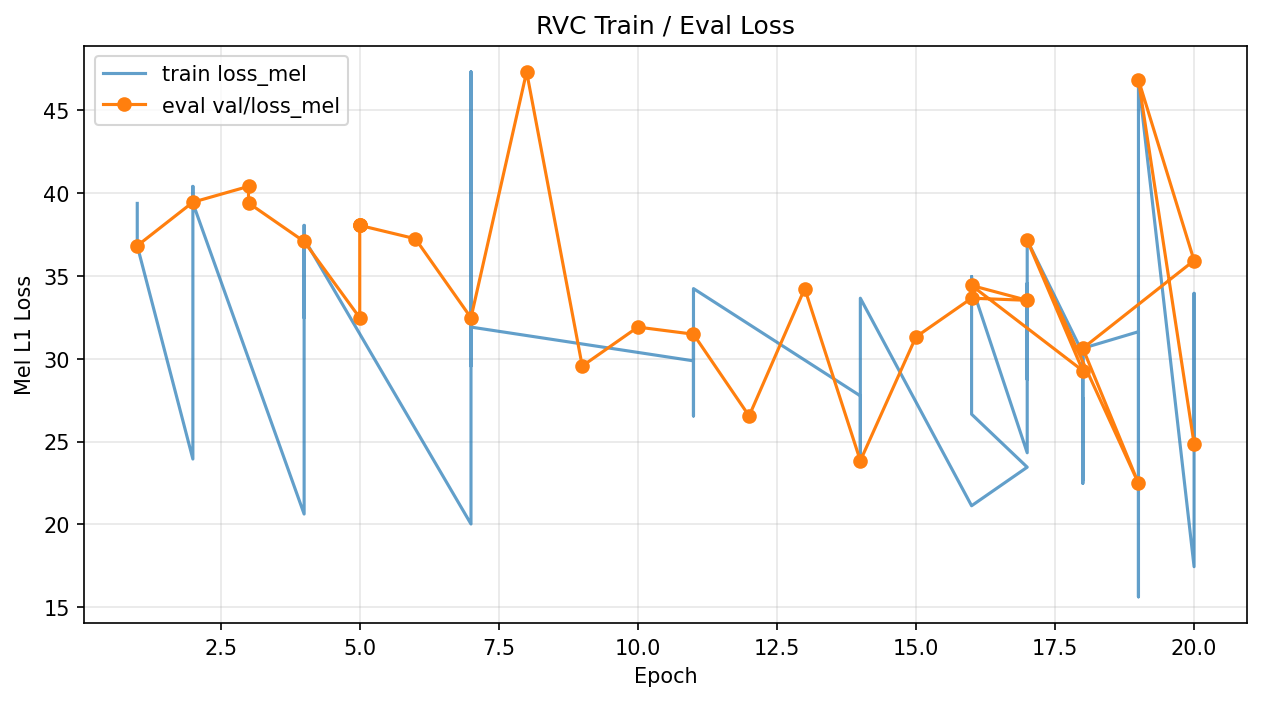

outputs/rvc_converted.wav


In [ ]:
# 查看实验 3-2 结果
import os
from IPython.display import Audio, Image, display

results = [
    ("Demo 微调 (course_rvc)", "outputs/rvc_loss_curve.png", "outputs/rvc_converted.wav"),
    (
        "AISHELL 微调 (aishell_voice, 30 epoch)",
        "outputs/rvc_aishell_loss_curve.png",
        "outputs/rvc_aishell_converted.wav",
    ),
]

for title, curve_path, audio_path in results:
    print(f"\n=== {title} ===")
    for p in [curve_path, audio_path]:
        if os.path.exists(p):
            print(p)
            if p.endswith(".png"):
                display(Image(filename=p))
            else:
                display(Audio(p))
        else:
            print(f"[缺失] {p}")